## 1. Data Loading and Exploration

Loading the raw dataset and performing an initial inspection to 
understand the structure, data types, and any data quality issues 
before cleaning.

In [17]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_excel('../data/anonymized_data.xlsx')
df.shape
df.info()
df.isnull().sum()
df.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    100 non-null    str    
 1   #sessions     100 non-null    int64  
 2   Pre Test1     100 non-null    int64  
 3   Post Test1    100 non-null    int64  
 4   change Test1  100 non-null    int64  
 5   Pre Test2     100 non-null    int64  
 6   Post Test2    100 non-null    int64  
 7   change Test2  100 non-null    int64  
 8   Pre Test3     100 non-null    float64
 9   Post Test3    100 non-null    float64
 10  change Test3  100 non-null    float64
 11  Pre Test4     100 non-null    int64  
 12  Post Test4    100 non-null    float64
 13  changeTest4   100 non-null    float64
 14  Pre Test5     100 non-null    int64  
 15  Post Test5    100 non-null    int64  
 16  changeTest5   100 non-null    int64  
 17  Pre Test6     100 non-null    int64  
 18  Post Test6    100 non-null    int64  
 19 

,#sessions,Pre Test1,Post Test1,change Test1,Pre Test2,Post Test2,change Test2,Pre Test3,Post Test3,change Test3,Pre Test4,Post Test4,changeTest4,Pre Test5,Post Test5,changeTest5,Pre Test6,Post Test6,changeTest6
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000,100.000000,100.000000,100.00000,100.000000,100.000000,100.00000,100.000000
mean,8.310000,57.920000,64.490000,6.570000,36.060000,46.340000,10.280000,0.045900,0.118600,0.072700,8.950000,30.334,21.384000,4.670000,11.43000,6.760000,0.900000,1.69000,0.790000
std,5.924943,22.353758,26.165555,14.664776,19.744745,22.773465,14.799727,0.159235,0.249071,0.208762,37.710051,79.348,69.424111,7.429201,12.32412,13.653075,0.893297,0.82505,0.742573
min,1.000000,0.000000,0.000000,-88.000000,0.000000,0.000000,-66.000000,0.000000,0.000000,-0.550000,0.000000,0.000,-187.000000,0.000000,0.00000,-40.000000,0.000000,0.00000,0.000000
25%,4.000000,43.000000,50.500000,1.750000,21.000000,31.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,3.75000,1.000000,0.000000,1.00000,0.000000
50%,7.000000,61.000000,70.000000,6.000000,36.000000,51.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,2.000000,7.00000,4.000000,1.000000,2.00000,1.000000
75%,10.250000,74.000000,83.000000,12.000000,52.250000,64.000000,16.000000,0.000000,0.075000,0.070000,0.000000,0.000,0.000000,5.250000,16.00000,10.000000,1.000000,2.00000,1.000000
max,34.000000,101.000000,107.000000,46.000000,79.000000,91.000000,48.000000,0.960000,1.200000,0.900000,240.000000,425.000,368.000000,40.000000,54.00000,40.000000,4.000000,4.00000,3.000000


### Initial Observations
- Dataset contains **100 patients** across **20 columns**
- **No missing values** detected across any column — data is complete
- Six clinical tests each with Pre, Post, and Change columns
- `#sessions` ranges from 1 to 34 with a mean of 8.31
- Change columns show inconsistent naming

## 2. Data Cleaning

The  dataset contains all six clinical tests in a single  table. 
To enable test-specific analysis, I split the data into separate tables
and removed invalid data

**Cleaning Process:**
- Split into six separate tables for each clinical measure
- Removed rows where Pre or Post score is zero or negative — these indicate 
  no assessment was performed rather than a true score of zero
- Recalculated the Change column from scratch (Post - Pre) rather than 
  trusting the imported change column which may contain data entry errors

In [18]:

#seperate table into tables for each type & clean up invalid data
tests = ["Test1", "Test2", "Test3", "Test4", "Test5", "Test6"]
tables = {}
for test in tests:
    subset = df[["#sessions","Pre "+test,"Post "+test]]
    subset.columns = ["Sessions", "Pre", "Post"]
    #remove invalid cols with zero or negative values
    subset = subset[(subset["Pre"]>0) & (subset["Post"]>0)]
    #Add a new column which is the change - not using the change col provided as may potentially be inaccurate
    subset["Change"] = subset["Post"] - subset["Pre"]
    #Add this subset into tables hashmap
    tables[test] = subset
    print(test + ": " + str(len(subset)) + " Valid Entries")

new_tables = {}
for test, table in tables.items():
    if len(table) >= 30:
        new_tables[test] = table
    else:
        print("Dropped: " + test)
tables = new_tables

Test1: 92 Valid Entries
Test2: 92 Valid Entries
Test3: 7 Valid Entries
Test4: 4 Valid Entries
Test5: 61 Valid Entries
Test6: 61 Valid Entries
Dropped: Test3
Dropped: Test4


### Cleaning Results

Test1: 92 Valid Entries

Test2: 92 Valid Entries

Test3: 7 Valid Entries

Test4: 4 Valid Entries

Test5: 61 Valid Entries

Test6: 61 Valid Entries

Test3 and Test4 have very small sample size so findings from these tests are unreliable and i risk drawing misleading conclusions from these samples. 

Dropped: Test3

Dropped: Test4

As the generally accepted minimum sample size for a normal distribution is 30, i have dropped all tables with less than 30 entries.

## 3. Exploratory Analysis

With clean separate tables for each clinical test, I can now explore 
the data to understand overall patterns.

Key questions to adress:
1. What do the test scores distributions look like across all tests before and after a session?
2. What percentage of patients improved, declined, or stayed the same?
3. Is session count correlated with improvement?
4. What number of sessions creates the biggest change?

### 3.1 Score Distributions

Before analysing improvement, I first examine the distribution of 
Pre and Post session for each test to understand:
- The range of patient functional levels at baseline
- Whether scores are normally distributed or skewed
- How scores shifted after session

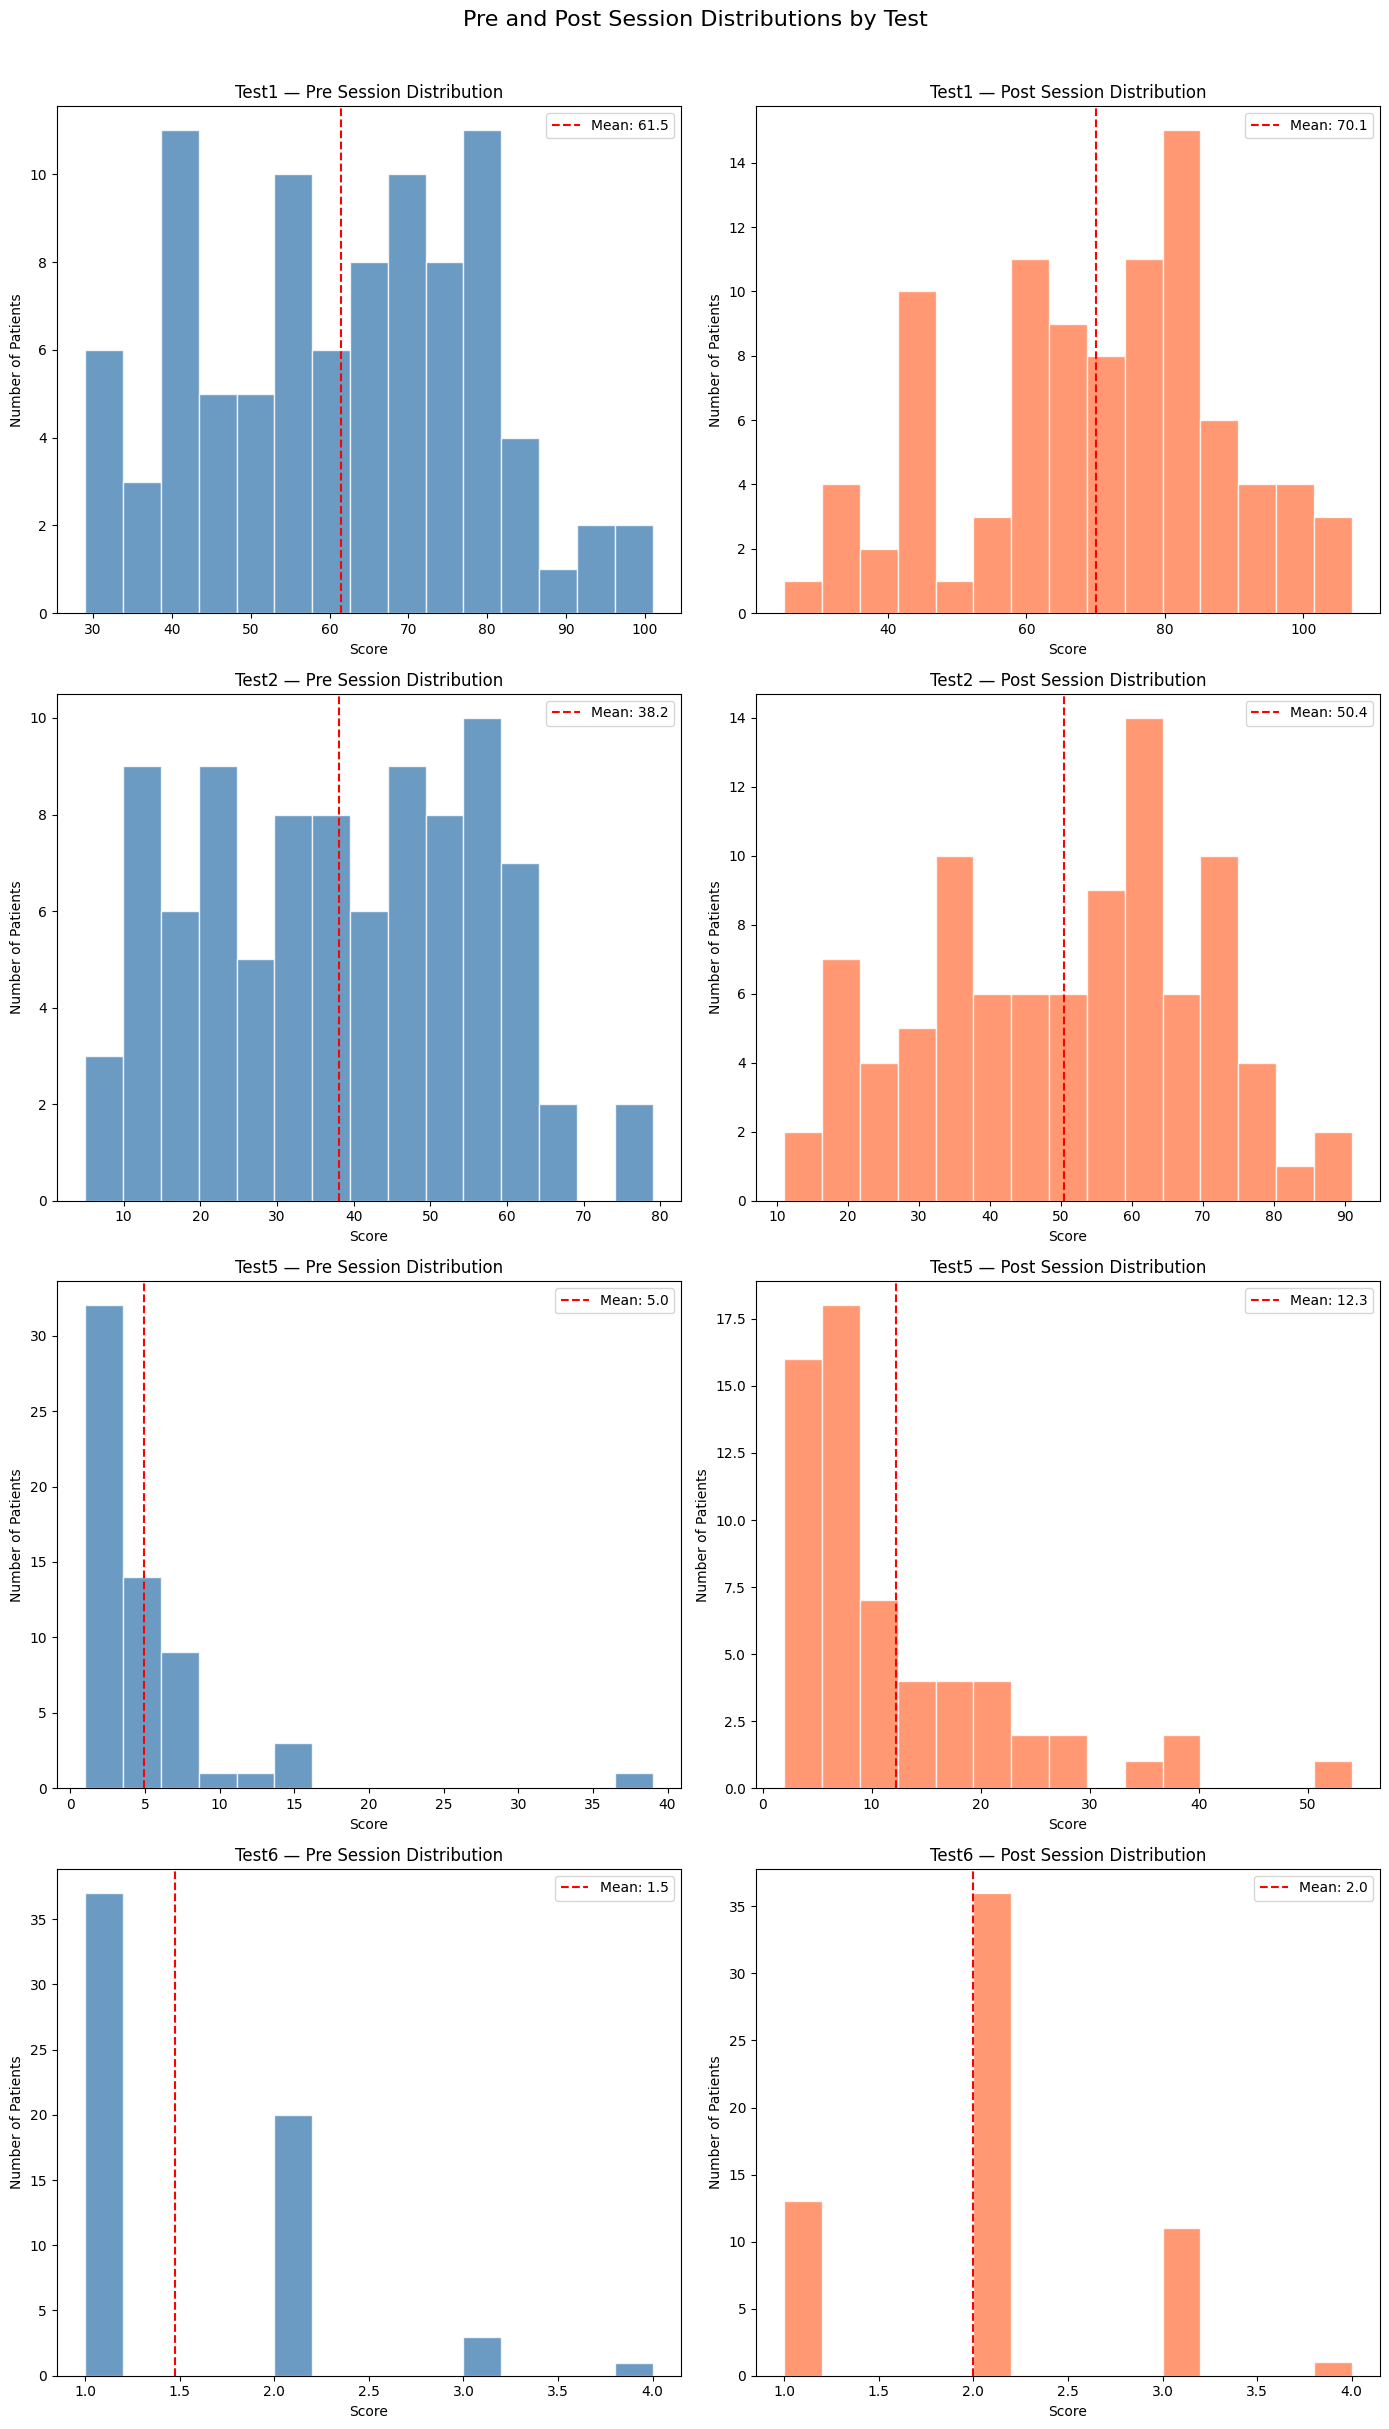

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(14, 24))

for i, (test, table) in enumerate(tables.items()):
    # Pre session distribution
    axes[i, 0].hist(table["Pre"], bins=15, color="steelblue", 
                    edgecolor="white", alpha=0.8)
    axes[i, 0].set_title(f"{test} — Pre Session Distribution")
    axes[i, 0].set_xlabel("Score")
    axes[i, 0].set_ylabel("Number of Patients")
    axes[i, 0].axvline(table["Pre"].mean(), color="red", 
                       linestyle="--", label=f"Mean: {table['Pre'].mean():.1f}")
    axes[i, 0].legend()

    # Post session distribution
    axes[i, 1].hist(table["Post"], bins=15, color="coral", 
                    edgecolor="white", alpha=0.8)
    axes[i, 1].set_title(f"{test} — Post Session Distribution")
    axes[i, 1].set_xlabel("Score")
    axes[i, 1].set_ylabel("Number of Patients")
    axes[i, 1].axvline(table["Post"].mean(), color="red", 
                       linestyle="--", label=f"Mean: {table['Post'].mean():.1f}")
    axes[i, 1].legend()
plt.suptitle("Pre and Post Session Distributions by Test", 
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Findings

- **Test1** — Pre scores are relatively evenly distributed with a mean of 61.5
  suggesting patients began session with all ranges of functional 
  independence. Post scores shift right indicating general improvement 
  across the cohort with the mean being 70.1.

- **Test2** — Similar pattern to Test1 with mean Pre score of 38.2 
  improving to 50.4 post session. The higher mean change than Test1 suggests daily function as measured by Test2 responds more strongly to rehabilitation than Test1.

- **Test5** — Pre Scores cluster at low values with exception of few outliers suggesting most 
  patients have high balance impairment at baseline. Post scores shift upward with a mean 
  improvement of 7.3 points, indicating rehabilitation meaningfully 
  improves balance ability. 

- **Test6** — Scores are concentrated across a narrow range of 
  categories reflecting the ordinal nature of the scale. Mean Pre 
  score of 1.5 improved to 2.0 post rehabilitation — a mean change 
  of 0.52 categories. While the absolute change appears small, any 
  upward movement on the Test6 scale represents a meaningful clinical 
  improvement in ambulatory function.

**Overall observation:** Post score distributions shift consistently in the 
direction of improvement across all four measures, providing initial 
visual evidence that rehabilitation is broadly effective.

### 3.2 Patient Improvement Rates

To assess the overall effectiveness of rehabilitation by each test, I classified each patient outcome into one of 
three categories:

- **Improved** — positive change score
- **Declined** — negative change score  
- **No change** — change score of zero

This gives a high level view of how many patients benefitted 
from rehabilitation across each test.

In [20]:
# For each test, what percentaege patients improved or declined throughout all sessions
for test, table in tables.items():
    total = len(table)
    improved = (table["Change"]>0).sum()
    declined = (table["Change"]<0).sum()
    same = (table["Change"]==0).sum()
    print(test)
    print("Improved: " + str(round(improved*100/total,1)) + "%")
    print("Declined: " + str(round(declined*100/total,1)) + "%")
    print("Same: " + str(round(same*100/total,2)) + "%")

Test1
Improved: 82.6%
Declined: 4.3%
Same: 13.04%
Test2
Improved: 79.3%
Declined: 2.2%
Same: 18.48%
Test5
Improved: 93.4%
Declined: 0.0%
Same: 6.56%
Test6
Improved: 49.2%
Declined: 0.0%
Same: 50.82%


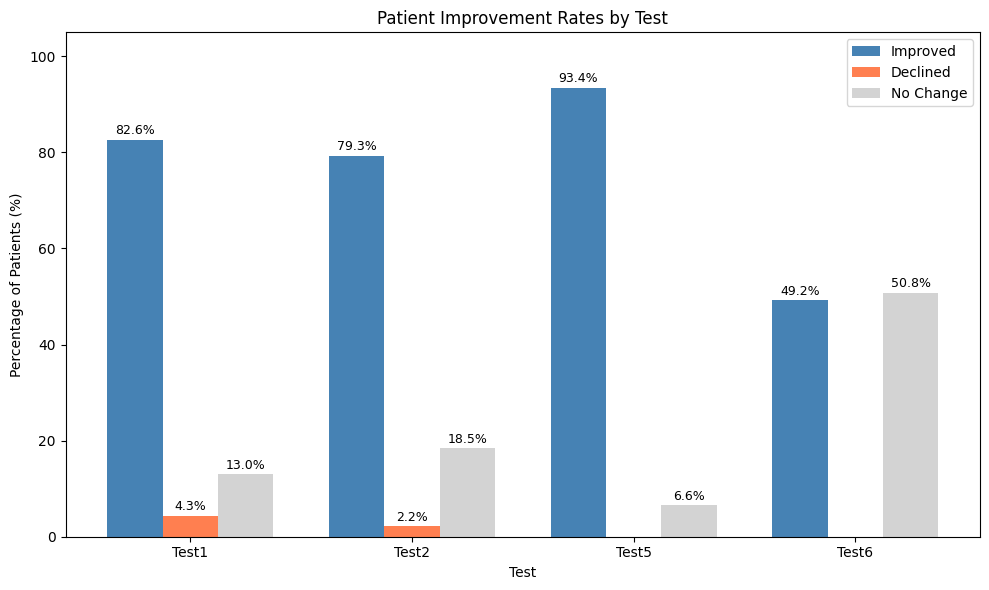

In [21]:
# Build data for chart
categories = list(tables.keys())
improved_pcts  = []
declined_pcts  = []
same_pcts      = []

for test, table in tables.items():
    total = len(table)
    improved_pcts.append((table["Change"] > 0).sum() / total * 100)
    declined_pcts.append((table["Change"] < 0).sum() / total * 100)
    same_pcts.append((table["Change"] == 0).sum() / total * 100)

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, improved_pcts, width, 
               label="Improved",   color="steelblue")
bars2 = ax.bar(x,          declined_pcts, width, 
               label="Declined",   color="coral")
bars3 = ax.bar(x + width,  same_pcts,     width, 
               label="No Change",  color="lightgrey")

# Add percentage labels on top of each bar
for bar in bars1 + bars2 + bars3:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f"{height:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Test")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_title("Patient Improvement Rates by Test")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### Findings

The following table and chart summarise the percentage of patients 
who improved, declined, or showed no change across each test:

|  Test  | Improved | Declined | No Change |
|--------|----------|----------|-----------|
| Test1  | 82.6%    | 4.4%     | 13.0%     |
| Test2  | 79.4%    | 2.2%     | 18.5%     |
| Test5  | 93.4%    | 0.0%     | 6.6%      |
| Test6  | 49.2%    | 0.0%     | 50.8%     |

**Key observations:**

- **Test5 demonstrates the strongest improvement rate at 93.4%** — 
  the vast majority of patients improved their balance ability 
  through sessions with zero patients declining

- **Test6 shows the lowest improvement rate at 49.2%** with 50.8% 
  of patients showing no change — consistent with the ordinal 
  nature of the Test6 scale where moving categories requires 
  significant functional improvement in ambulatory ability

- **Test1 and Test2 show similarly strong improvement rates** at 
  82.6% and 79.4% respectively — suggesting daily living 
  function and independence respond strongly to sessions

- **Decline rates are consistently low or zero** across all 
  tests — Test1 4.4%, Test2 2.2%, Test5 0%, Test6 0% — indicating 
  sessions carry minimal risk of functional deterioration

- **Overall** the majority of patients improved on every test, 
  with Test5 and the two functional independence tests showing 
  particularly strong positive outcomes

### 3.3 Session Count vs Improvement

A key research question is whether attending more sessions leads 
to greater functional improvement. I examine this through the correlation coefficient.

A positive correlation indicates more sessions are associated 
with greater improvement. The strength of correlation is 
interpreted as follows:

| Range        | Interpretation          |
|--------------|-------------------------|
| 0.7 to 1.0   | Strong positive         |
| 0.4 to 0.7   | Moderate positive       |
| 0.1 to 0.4   | Weak positive           |
| 0.0          | No relationship         |
| Negative     | More sessions = decline |

In [22]:
print("Correlation: Session Count vs Change Score")
print("=" * 45)

for test, table in tables.items():
    corr = table["Sessions"].corr(table["Change"])
    
    # Interpret strength
    if abs(corr) >= 0.7:
        strength = "Strong"
    elif abs(corr) >= 0.4:
        strength = "Moderate"
    elif abs(corr) >= 0.1:
        strength = "Weak"
    else:
        strength = "No relationship"
    
    direction = "positive" if corr > 0 else "negative"
    print(f"\n{test}: {corr:.3f} — {strength} {direction}")

Correlation: Session Count vs Change Score

Test1: 0.441 — Moderate positive

Test2: 0.430 — Moderate positive

Test5: 0.189 — Weak positive

Test6: 0.305 — Weak positive


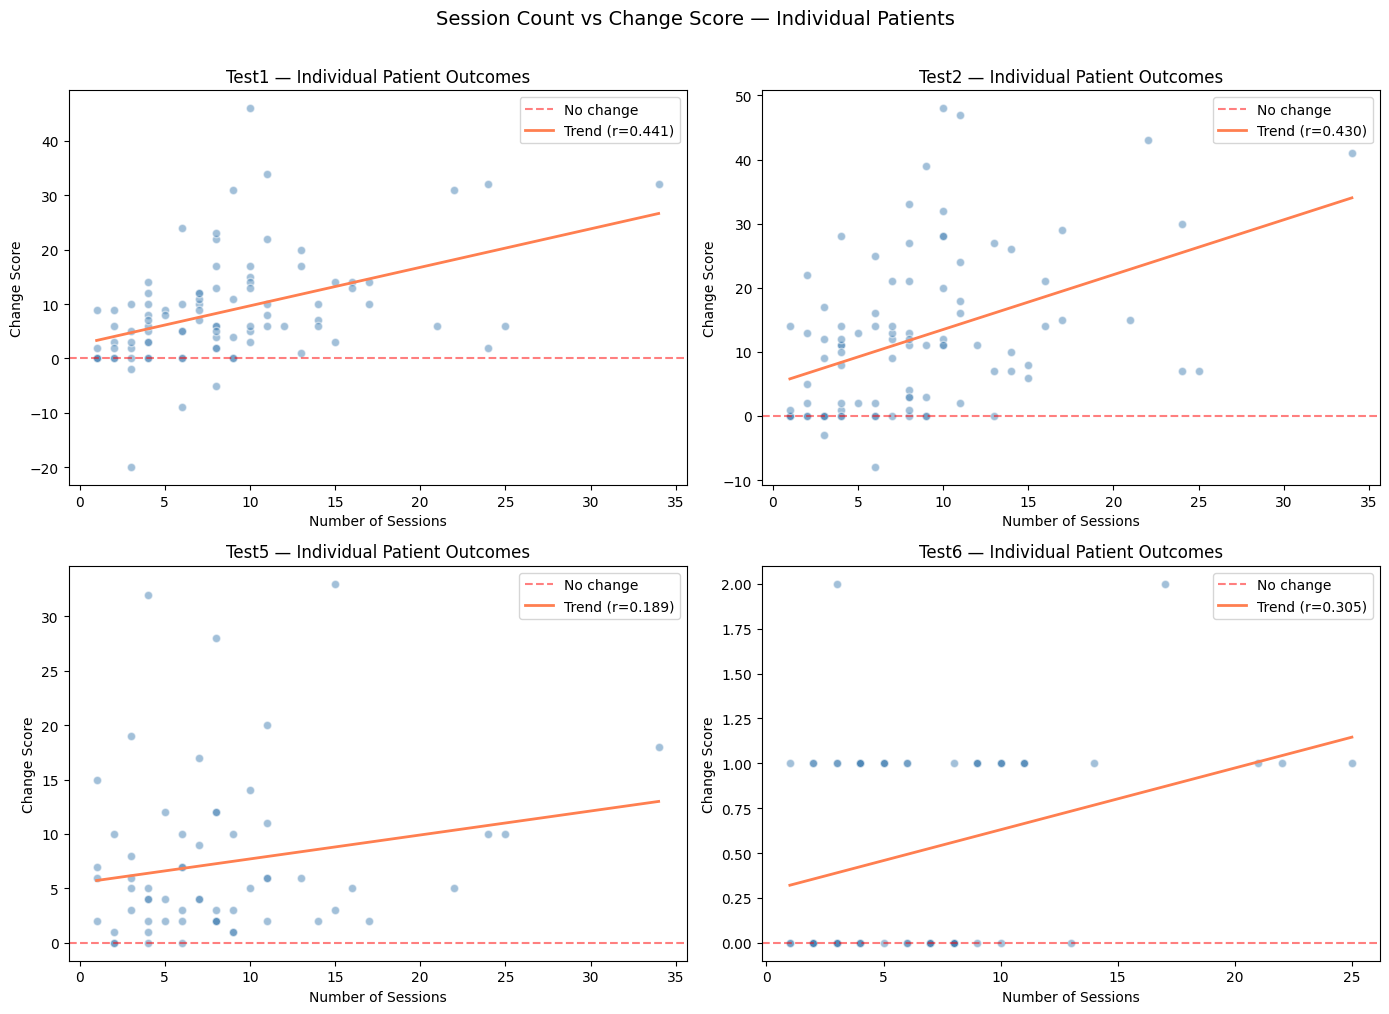

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (test, table) in enumerate(tables.items()):
    corr = table["Sessions"].corr(table["Change"])
    
    axes[i].scatter(table["Sessions"], table["Change"],
                    alpha=0.5, color="steelblue", edgecolors="white")
    axes[i].axhline(y=0, color="red", linestyle="--",
                    alpha=0.5, label="No change")
    
    # Add trend line
    z = np.polyfit(table["Sessions"], table["Change"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(table["Sessions"].min(), 
                         table["Sessions"].max(), 100)
    axes[i].plot(x_line, p(x_line), color="coral", 
                 linewidth=2, label=f"Trend (r={corr:.3f})")
    
    axes[i].set_title(f"{test} — Individual Patient Outcomes")
    axes[i].set_xlabel("Number of Sessions")
    axes[i].set_ylabel("Change Score")
    axes[i].legend()

plt.suptitle("Session Count vs Change Score — Individual Patients",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Findings

|  Test  | Correlation | Strength        |
|--------|-------------|-----------------|
| Test1  | 0.441       | Moderate positive |
| Test2  | 0.430       | Moderate positive |
| Test5  | 0.189       | Weak positive   |
| Test6  | 0.305       | Weak positive   |

All four tests show a positive correlation between session count 
and improvement — confirming that patients who attend more sessions 
tend to show greater functional recovery.

**Key observations:**

- **Test1 and Test2 show the strongest relationship** with moderate 
  positive correlations of 0.441 and 0.430 respectively — 
  suggesting functional independence and daily living ability 
  respond most consistently to increased session count

- **Test5 shows the weakest correlation at 0.189** — balance 
  improvement appears less dependent on session count than 
  functional independence measures, suggesting balance recovery 
  may be influenced more strongly by patient specific factors 
  such as diagnosis or baseline severity

- **Test6 shows a weak positive correlation of 0.305** — consistent 
  with the earlier finding that Test5 scores are difficult to move 
  given the ordinal nature of the scale, even with more sessions

- **No negative correlations were detected** — more sessions 
  never associated with worse outcomes across any test

**Overall:** While all correlations are positive, the moderate 
strength of Test1 and Test2 correlations and weak strength of Test5 
and Test6 suggest that session count is one of several factors 
influencing rehabilitation outcomes. 

### 3.4 Optimal Session Count

Building on the correlation analysis, I now identify which session 
counts are associated with the greatest average improvement across 
each test.

In [24]:
print("Average Change by Session Count")
print("=" * 45)

for test, table in tables.items():
    session_avg = table.groupby("Sessions")["Change"].agg([
        "mean", "count"
    ]).reset_index()
    session_avg.columns = ["Sessions", "Avg Change", "Patient Count"]
    
    # Only consider session counts with at least 3 patients
    # for reliability
    reliable = session_avg[session_avg["Patient Count"] >= 3]
    
    if len(reliable) > 0:
        best_session = reliable.loc[
            reliable["Avg Change"].idxmax(), "Sessions"
        ]
        best_change = reliable["Avg Change"].max()
        
        print(f"\n{test}")
        print(f"  Best session count: {best_session} sessions")
        print(f"  Average change:     {best_change:.2f} points")
        print(f"  Based on:           {reliable.loc[reliable['Sessions']==best_session, 'Patient Count'].values[0]} patients")

Average Change by Session Count

Test1
  Best session count: 11 sessions
  Average change:     16.00 points
  Based on:           5 patients

Test2
  Best session count: 10 sessions
  Average change:     23.75 points
  Based on:           8 patients

Test5
  Best session count: 11 sessions
  Average change:     9.00 points
  Based on:           5 patients

Test6
  Best session count: 11 sessions
  Average change:     1.00 points
  Based on:           3 patients


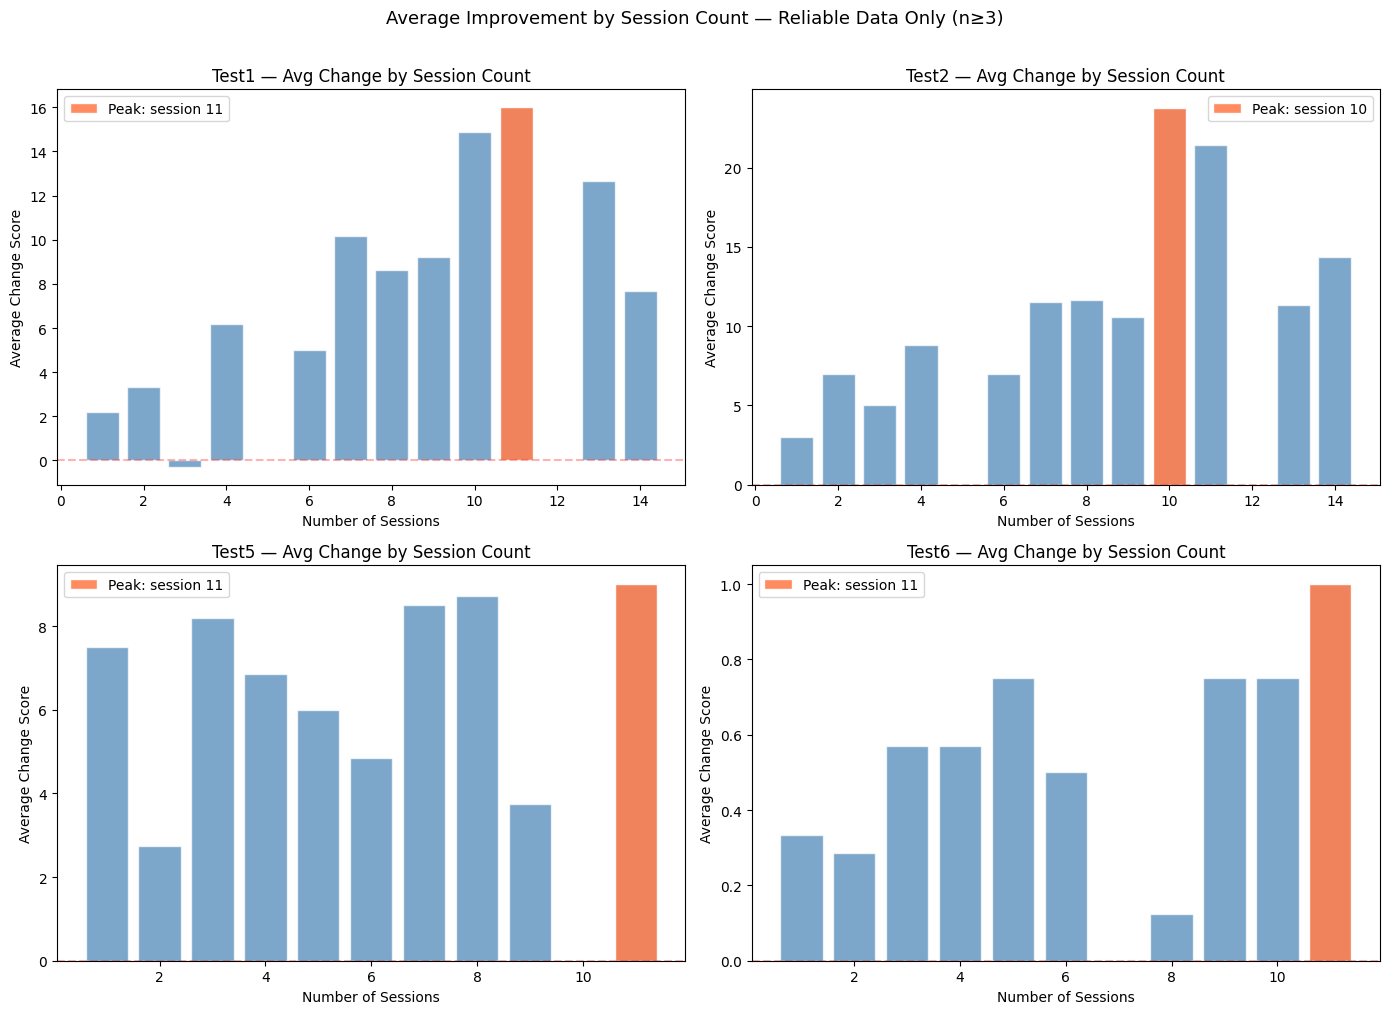

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (test, table) in enumerate(tables.items()):
    session_avg = table.groupby("Sessions")["Change"].agg([
        "mean", "count"
    ]).reset_index()
    session_avg.columns = ["Sessions", "Avg Change", "Patient Count"]
    
    # Filter for reliability
    reliable = session_avg[session_avg["Patient Count"] >= 3]
    
    # Find peak session
    if len(reliable) > 0:
        peak_session = reliable.loc[
            reliable["Avg Change"].idxmax(), "Sessions"
        ]
        peak_change = reliable["Avg Change"].max()
    
    # Bar chart — avg change per session count
    axes[i].bar(reliable["Sessions"], reliable["Avg Change"],
                color="steelblue", alpha=0.7, edgecolor="white")
    
    # Highlight peak bar
    axes[i].bar(peak_session, peak_change,
                color="coral", alpha=0.9, 
                edgecolor="white", label=f"Peak: session {peak_session}")
    
    axes[i].axhline(y=0, color="red", linestyle="--", alpha=0.3)
    axes[i].set_title(f"{test} — Avg Change by Session Count")
    axes[i].set_xlabel("Number of Sessions")
    axes[i].set_ylabel("Average Change Score")
    axes[i].legend()

plt.suptitle("Average Improvement by Session Count — Reliable Data Only (n≥3)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Findings

|  Test  | Best Session Count | Avg Change at Peak | Patients |
|--------|-------------------|-------------------|----------|
| Test1  | 11 sessions       | 16.00 points      | n=5      |
| Test2  | 10 sessions       | 23.75 points      | n=8      |
| Test5  | 11 sessions       | 9.00 points       | n=5      |
| Test6  | 11 sessions       | 1.00 points       | n=3      |

**Key observations:**

- **Peak improvement consistently occurs around 10-11 sessions** 
  across all four tests — suggesting this as a clinically meaningful 
  target for rehabilitation programme length

- **Test2 shows the strongest peak improvement at 23.75 points** 
  at session 10 — suggesting daily living function responds most 
  dramatically to sustained rehabilitation intensity

- **Test1 shows strong peak improvement of 16.00 points** at session 
  11 — consistent with Test2 given both measure functional independence 
  and daily living ability

- **Test5 peaks at 9.00 points** at session 11 — a meaningful 
  improvement in balance ability, consistent with the earlier 
  finding that Test5 has the highest overall improvement rate at 93.4%

- **Test6 shows the smallest peak change of 1.00 category** at 
  session 11 — consistent with the ordinal scale structure of Test6 
  where even a single category improvement represents significant 
  functional gain in ambulatory ability

**Important caveat:** Peak session counts are based on small patient 
subgroups. While the consistent 
pattern across all four tests strengthens confidence in the 10-11 
session finding, a larger dataset would be needed to confirm this 
threshold with statistical reliability. This finding should be 
interpreted as indicative rather than definitive.

**Clinical implication:** The consistent peak at 10-11 sessions 
across all tests suggests rehabilitation programmes of at least 
10-11 sessions may be needed to achieve maximum functional recovery. 
Programmes shorter than this threshold may not fully realise the 
potential improvement available to patients.